### Llamada de paquetes y base de datos

In [60]:
# --- Librerías estándar ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Visualización ---
import seaborn as sns
from matplotlib import rcParams
from matplotlib.colors import ListedColormap

# --- Statsmodels ---
import statsmodels.api as sm
from scipy.stats import ttest_ind

# --- Scikit-learn ---
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    recall_score,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline

In [2]:
EPH = pd.read_csv("EPH_merged.csv", low_memory=False)

In [3]:
EPH

,CODUSU,NRO_HOGAR,COMPONENTE,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_INAC,...,ad_equiv_hogar,ingreso_necesario,pobre,edad2,educ,edad_rango,ingreso_total_familiar,ingreso_total_familiar_millones,CH03_str,IX_TOT
0,125666,1,1,1,36,1,4,3,1.0,NaN,...,4.18,857.1926,1,1296,8.0,31-50,678727.0,0.678727,jefe,5.0
1,125666,1,2,2,35,1,4,2,3.0,4.0,...,4.18,857.1926,1,1225,6.0,31-50,678727.0,0.678727,cónyuge/pareja,5.0
2,125666,1,3,2,15,5,4,3,3.0,3.0,...,4.18,857.1926,1,225,7.0,13-17,678727.0,0.678727,hijo/hijastro,5.0
3,125666,1,4,1,12,5,4,3,3.0,3.0,...,4.18,857.1926,1,144,8.0,6-12,678727.0,0.678727,hijo/hijastro,5.0
4,125666,1,5,1,10,5,4,1,3.0,3.0,...,4.18,857.1926,1,100,5.0,6-12,678727.0,0.678727,hijo/hijastro,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19034,TQRMNOQYSHMKKRCDEHIBB00882443,1,1,2,90,4,1,4,3.0,1.0,...,2.15,785130.5500,0,8100,12.0,50+,3750000.0,3.750000,1,3.0
19035,TQRMNOQYSHMKKRCDEHIBB00882443,1,2,2,60,5,1,6,1.0,0.0,...,2.15,785130.5500,0,3600,17.0,50+,3750000.0,3.750000,3,3.0
19036,TQRMNOQYSHMKKRCDEHIBB00882443,1,3,2,22,5,1,5,3.0,3.0,...,2.15,785130.5500,0,484,15.0,18-30,3750000.0,3.750000,5,3.0
19037,TQRMNOPPVHKOKSCDEHIBB00860370,1,1,1,25,1,4,2,1.0,0.0,...,1.78,650015.0600,0,625,6.0,18-30,1075000.0,1.075000,1,2.0


In [4]:
EPH.columns

Index(['CODUSU', 'NRO_HOGAR', 'COMPONENTE', 'CH04', 'CH06', 'CH07', 'CH08',
       'NIVEL_ED', 'ESTADO', 'CAT_INAC', 'CAT_OCUP', 'EMPLEO', 'PP02B',
       'PP02E', 'PP02H', 'PP02I', 'PP03C', 'PP03G', 'PP03I', 'PP04A', 'PP04G',
       'PP05B3', 'PP05H', 'PP05I', 'PP05J', 'PP05K', 'PP07A', 'PP07I3',
       'PP07J', 'PP07K', 'PP08D1', 'P21', 'ITF', 'DECINDR', 'IPCF', 'ANIO',
       'CH03', 'CH12', 'CH13', 'CH14', 'PP3E_TOT', 'PP3F_TOT', 'horastrab',
       'trabaja', 'adulto_equiv', 'ad_equiv_hogar', 'ingreso_necesario',
       'pobre', 'edad2', 'educ', 'edad_rango', 'ingreso_total_familiar',
       'ingreso_total_familiar_millones', 'CH03_str', 'IX_TOT'],
      dtype='object')

# PUNTO A: Enfoque de validación

In [5]:
EPH.isna().mean().sort_values(ascending=False)

EMPLEO                             0.771364
PP05B3                             0.771364
PP05I                              0.771364
PP07I3                             0.771364
PP05K                              0.771364
PP05J                              0.771364
PP04G                              0.737066
PP05H                              0.727874
PP07A                              0.672357
PP07J                              0.652818
PP07K                              0.641368
PP03C                              0.608856
PP04A                              0.596985
PP03I                              0.592258
PP03G                              0.592048
PP02B                              0.490992
PP02E                              0.488051
PP02H                              0.300016
PP02I                              0.299806
CAT_OCUP                           0.293398
PP08D1                             0.280372
PP3E_TOT                           0.280372
PP3F_TOT                        

Porcentaje de personas con 0 horas trabajadas: 62.94%


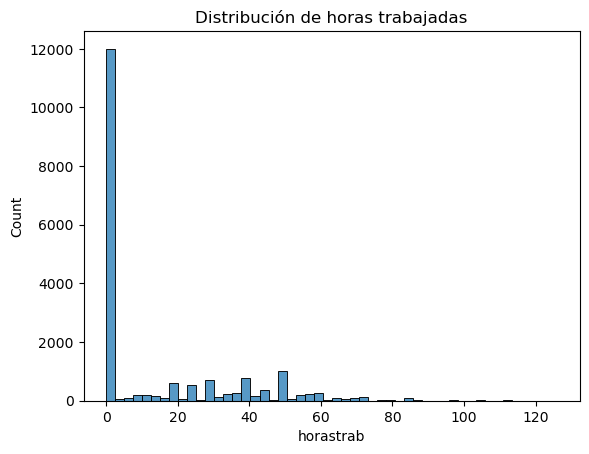

In [6]:
# porcentaje de ceros
porc_ceros = (EPH['horastrab'] == 0).mean() * 100
print(f"Porcentaje de personas con 0 horas trabajadas: {porc_ceros:.2f}%")

# histograma
sns.histplot(EPH['horastrab'], bins=50)
plt.title('Distribución de horas trabajadas')
plt.show()

In [55]:
EPH = EPH.copy()

EPH['log_horastrab'] = np.log1p(EPH['horastrab']) #Debido a la distribución de horas de horastrab (mayormente distribuidas en 0)

# 1. Imputación de variables (con la media)
EPH['educ'] = pd.to_numeric(EPH['educ'], errors='coerce')
EPH['educ'] = EPH['educ'].fillna(EPH['educ'].mean())

EPH['CH06'] = pd.to_numeric(EPH['CH06'], errors='coerce')
EPH['CH06'] = EPH['CH06'].fillna(EPH['CH06'].median())

EPH['IX_TOT'] = pd.to_numeric(EPH['IX_TOT'], errors='coerce')
EPH['IX_TOT'] = EPH['IX_TOT'].fillna(EPH['IX_TOT'].median())

EPH['horastrab'] = EPH['horastrab'].fillna(0)


# 2. Variables dummies

EPH['mujer'] = (EPH['CH04'] == 2).astype(int)
EPH['log_horastrab'] = np.log1p(EPH['horastrab'])
EPH['en_pareja'] = EPH['CH07'].isin([1, 2]).astype(int)

EPH['sin_cobertura'] = EPH['CH08'].isin([4, 9]).astype(int)
EPH['solo_publica'] = EPH['CH08'].isin([3, 13, 23]).astype(int)
EPH['con_obra_social_o_prepaga'] = EPH['CH08'].isin([1, 2, 12, 123]).astype(int)

EPH['ocupado'] = (EPH['ESTADO'] == 1).astype(int)

EPH['inactivo_no_jubilado'] = EPH['CAT_INAC'].isin([3,4,5,6,7]).astype(int)
EPH['trabajo_no_rem'] = (EPH['CAT_OCUP'] == 4).astype(int)
EPH['cuenta_propia_o_patron'] = EPH['CAT_OCUP'].isin([1,2]).astype(int)


dummy_vars = [
    'mujer', 'en_pareja', 'ocupado',
    'solo_publica', 'con_obra_social_o_prepaga',
    'trabajo_no_rem', 'cuenta_propia_o_informal', 'inactivo_no_jubilado'
]
for c in dummy_vars:
    EPH[c] = EPH[c].fillna(0)


# 3. Separaración respondieron y norespondieron

respondieron = EPH[EPH['ITF'] > 0].copy()
norespondieron = EPH[EPH['ITF'] == 0].copy()

respondieron_2005 = respondieron[respondieron['ANIO'] == 2005].copy()
respondieron_2025 = respondieron[respondieron['ANIO'] == 2025].copy()
norespondieron_2005 = norespondieron[norespondieron['ANIO'] == 2005].copy()
norespondieron_2025 = norespondieron[norespondieron['ANIO'] == 2025].copy()

In [62]:
# 4. Definición X_vars y y_var
X_vars = ['CH06', 'educ', 'IX_TOT', 'log_horastrab'] + dummy_vars
X_vars = list(dict.fromkeys(X_vars))  # eliminar duplicados
y_var = 'pobre'


# 5. Función para split 70/30 con intercept
def split_train_test_by_df(df, X_vars, y_var, test_size=0.3, random_state=444):
    X = df[X_vars].copy()
    y = df[y_var].copy()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    X_train = X_train.copy()
    X_test = X_test.copy()
    X_train.insert(0, 'intercept', 1)
    X_test.insert(0, 'intercept', 1)
    return X_train, X_test, y_train, y_test


X_train_2005, X_test_2005, y_train_2005, y_test_2005 = split_train_test_by_df(respondieron_2005, X_vars, y_var)
X_train_2025, X_test_2025, y_train_2025, y_test_2025 = split_train_test_by_df(respondieron_2025, X_vars, y_var)

print(f"2005: X_train={X_train_2005.shape}, X_test={X_test_2005.shape}")
print(f"2025: X_train={X_train_2025.shape}, X_test={X_test_2025.shape}")


# 6. Tabla de diferencia de medias con t-test
def diff_means_table(X_train, X_test):
    cols = [c for c in X_train.columns if c != 'intercept']
    train_means = X_train[cols].mean()
    test_means = X_test[cols].mean()
    diff = train_means - test_means
    pooled_std = ((X_train[cols].var(ddof=1) + X_test[cols].var(ddof=1)) / 2)**0.5
    std_diff = diff / pooled_std.replace(0, np.nan)

    # t-test independiente para cada variable
    tvals, pvals = [], []
    for c in cols:
        t, p = ttest_ind(X_train[c], X_test[c], equal_var=False, nan_policy='omit')
        tvals.append(t)
        pvals.append(p)

    tabla = pd.DataFrame({
        'train_mean': train_means,
        'test_mean': test_means,
        'diff': diff,
        'std_diff': std_diff,
        'tval': tvals,
        'pval': pvals
    })

    return tabla


# 7. Aplicar a ambos años
tabla_diff_2005 = diff_means_table(X_train_2005, X_test_2005)
tabla_diff_2025 = diff_means_table(X_train_2025, X_test_2025)

print("\nDiferencia de medias 2025")
print(tabla_diff_2025.round(4))


# 8. Variables con mayor diferencia absoluta
print("\nVariables con |diff| > 0.02 en 2025:")
print(tabla_diff_2025.loc[tabla_diff_2025['diff'].abs() > 0.02])

2005: X_train=(6494, 13), X_test=(2784, 13)
2025: X_train=(6055, 13), X_test=(2596, 13)

Diferencia de medias 2025
                           train_mean  test_mean    diff  std_diff    tval  \
CH06                          35.4226    35.5612 -0.1386   -0.0065 -0.2760   
educ                          10.0294    10.0140  0.0153    0.0036  0.1562   
IX_TOT                         4.1803     4.0986  0.0817    0.0405  1.7340   
log_horastrab                  1.4290     1.4076  0.0213    0.0122  0.5187   
mujer                          0.5217     0.5139  0.0079    0.0157  0.6695   
en_pareja                      0.3308     0.3247  0.0061    0.0129  0.5517   
ocupado                        0.4461     0.4426  0.0035    0.0070  0.2980   
solo_publica                   0.0461     0.0443  0.0018    0.0086  0.3663   
con_obra_social_o_prepaga      0.6091     0.6090  0.0001    0.0001  0.0061   
trabajo_no_rem                 0.0045     0.0054 -0.0009   -0.0133 -0.5580   
cuenta_propia_o_informal   

In [63]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Lista de todas las variables
predictors = [
   'mujer', 'en_pareja', 'ocupado',
    'solo_publica', 'con_obra_social_o_prepaga',
    'trabajo_no_rem', 'cuenta_propia_o_informal', 'inactivo_no_jubilado', 'CH06', 'educ', 'IX_TOT', 'log_horastrab'
]

# Subset de datos
X = respondieron_2025[predictors].copy()

# Calcular VIF
vif_data = pd.DataFrame()
vif_data['variable'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Mostrar resultados
print(vif_data)


                     variable        VIF
0                       mujer   2.218101
1                   en_pareja   1.905661
2                     ocupado  12.715308
3                solo_publica   1.149650
4   con_obra_social_o_prepaga   3.114315
5              trabajo_no_rem   1.017040
6    cuenta_propia_o_informal   1.379041
7        inactivo_no_jubilado   3.880307
8                        CH06   4.935555
9                        educ   7.077014
10                     IX_TOT   4.632325
11              log_horastrab   9.385133


# PUNTO B: Modelo de Regresión Logística

In [9]:
# 8. Estimar regresión logística (2005 y 2025)
def estimar_logit(X_train, y_train):
    model = sm.Logit(y_train, X_train)
    result = model.fit(disp=False)
    return result

logit_2005 = estimar_logit(X_train_2005, y_train_2005)
logit_2025 = estimar_logit(X_train_2025, y_train_2025)

In [10]:
# 9. Generación de cuadro de información de la regresión

def tabla_from_logit_result(result):
    coef = result.params
    std_err = result.bse
    pval = result.pvalues
    odds_ratio = np.exp(coef)
    tabla = pd.DataFrame({
        'coef': coef,
        'std_err': std_err,
        'pval': pval,
        'odds_ratio': odds_ratio
    })
    return tabla

# 10. Generamos las tablas a partir de los resultados
tabla_logit_2005 = tabla_from_logit_result(logit_2005)
tabla_logit_2025 = tabla_from_logit_result(logit_2025)

def agregar_significancia(tabla):
    def stars(p):
        if p < 0.001: return '***'
        elif p < 0.01: return '**'
        elif p < 0.05: return '*'
        elif p < 0.1: return '.'
        else: return ''
    tabla = tabla.copy()
    tabla['sig'] = tabla['pval'].apply(stars)
    return tabla

tabla_logit_2005_sig = agregar_significancia(tabla_logit_2005)
tabla_logit_2025_sig = agregar_significancia(tabla_logit_2025)

print("\nRegresión Logística 2005")
print(tabla_logit_2005_sig[['coef', 'std_err', 'odds_ratio', 'pval', 'sig']].round(4))

print("\nRegresión Logística 2025")
print(tabla_logit_2025_sig[['coef', 'std_err', 'odds_ratio', 'pval', 'sig']].round(4))


Regresión Logística 2005
                             coef  std_err  odds_ratio    pval  sig
intercept                  0.5065   0.1704      1.6595  0.0030   **
CH06                      -0.0058   0.0021      0.9942  0.0066   **
educ                      -0.0852   0.0081      0.9183  0.0000  ***
IX_TOT                     0.2225   0.0135      1.2492  0.0000  ***
log_horastrab              0.0044   0.0466      1.0044  0.9248     
mujer                     -0.0665   0.0631      0.9356  0.2917     
en_pareja                  0.2583   0.0792      1.2947  0.0011   **
ocupado                   -0.3500   0.1871      0.7047  0.0614    .
solo_publica              -1.5283   1.2010      0.2169  0.2032     
con_obra_social_o_prepaga -2.0141   0.0630      0.1334  0.0000  ***
trabajo_no_rem             0.3183   0.2770      1.3748  0.2505     
cuenta_propia_o_informal  -0.0422   0.1125      0.9587  0.7078     
inactivo_no_jubilado       0.1452   0.1179      1.1563  0.2179     

Regresión Logística 2

In [11]:
X_train_2005[dummy_vars].corr()

,mujer,en_pareja,ocupado,solo_publica,con_obra_social_o_prepaga,trabajo_no_rem,cuenta_propia_o_informal,inactivo_no_jubilado
mujer,1.000000,-0.024985,-0.127741,0.023800,0.025211,0.017981,-0.115809,0.125872
en_pareja,-0.024985,1.000000,0.352869,0.007957,0.119122,-0.012163,0.190608,-0.380289
ocupado,-0.127741,0.352869,1.000000,-0.005935,0.001572,0.139525,0.361145,-0.767732
solo_publica,0.023800,0.007957,-0.005935,1.000000,-0.027646,-0.002737,0.012987,0.012108
con_obra_social_o_prepaga,0.025211,0.119122,0.001572,-0.027646,1.000000,-0.026103,-0.086128,-0.088377
trabajo_no_rem,0.017981,-0.012163,0.139525,-0.002737,-0.026103,1.000000,-0.035917,-0.111626
cuenta_propia_o_informal,-0.115809,0.190608,0.361145,0.012987,-0.086128,-0.035917,1.000000,-0.329791
inactivo_no_jubilado,0.125872,-0.380289,-0.767732,0.012108,-0.088377,-0.111626,-0.329791,1.000000


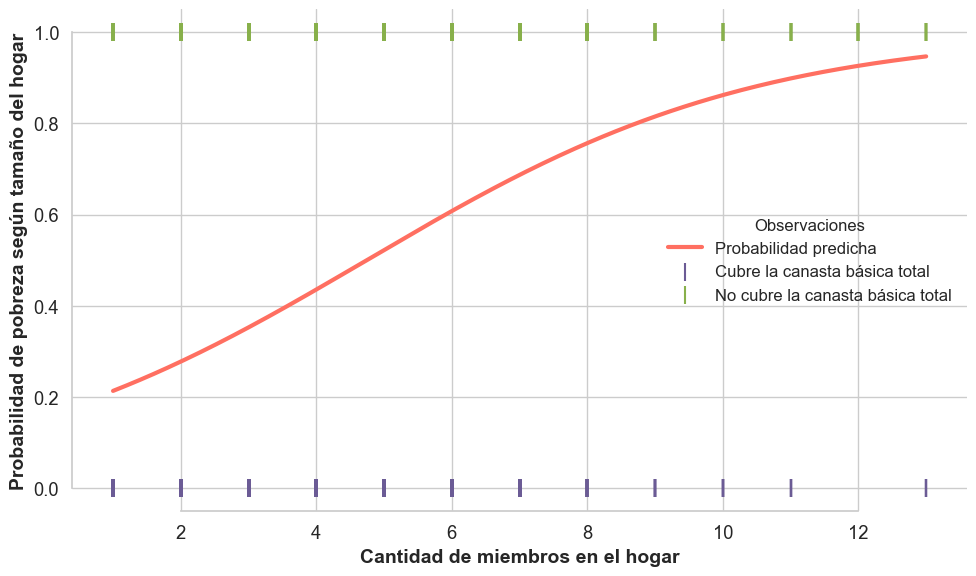

In [64]:
# Estilo seaborn y colores pastel
sns.set(style="whitegrid", palette="pastel", font_scale=1.2)

# Predictor: IX_TOT (tamaño del hogar)
X_2025 = sm.add_constant(X_train_2025['IX_TOT'])
y_2025 = y_train_2025

# Ajustar modelo logit simple con IX_TOT
logit_ix = sm.Logit(y_2025, X_2025).fit(disp=0)

# Rango de valores de IX_TOT para graficar la curva
ix_range = np.linspace(X_train_2025['IX_TOT'].min(), X_train_2025['IX_TOT'].max(), 300)
X_range = sm.add_constant(ix_range)

# Probabilidades predichas
prob_preds = logit_ix.predict(X_range)

# Colores pastel
color_curve = "#FF6F61"  # rojo pastel
color_0 = "#6B5B95"      # azul pastel
color_1 = "#88B04B"      # verde pastel

# Graficar
plt.figure(figsize=(10,6))

# 🔹 Curva logística predicha
plt.plot(ix_range, prob_preds, color=color_curve, linewidth=3, label='Probabilidad predicha')

# 🔸 Ticks de observaciones reales
plt.scatter(X_train_2025.loc[y_2025==0, 'IX_TOT'], 
            np.zeros(sum(y_2025==0)), 
            marker='|', color=color_0, s=150, label='Cubre la canasta básica total')

plt.scatter(X_train_2025.loc[y_2025==1, 'IX_TOT'], 
            np.ones(sum(y_2025==1)), 
            marker='|', color=color_1, s=150, label='No cubre la canasta básica total')

# Límites y etiquetas
plt.ylim(-0.05, 1.05)
plt.xlabel('Cantidad de miembros en el hogar', fontsize=14, weight='bold')
plt.ylabel('Probabilidad de pobreza según tamaño del hogar', fontsize=14, weight='bold')


# Leyenda más limpia
plt.legend(title='Observaciones', fontsize=12, title_fontsize=12)

# Remover bordes extra
sns.despine(trim=True)

plt.tight_layout()
plt.show()


# PUNTO C: Método de Vecinos Cercanos (KNN)

## Ejercicio 5)

### 2025

In [13]:
X_train_2025 
y_train_2025

# Escalar X_train
scaler = StandardScaler().fit(X_train_2025)
X_train_scaled = scaler.transform(X_train_2025)

Ks = [1, 5, 10]

for K in Ks:
    knn = KNeighborsClassifier(n_neighbors=K)
    knn.fit(X_train_scaled, y_train_2025)

    # Predicciones sobre el mismo conjunto de entrenamiento
    y_pred = knn.predict(X_train_scaled)

    # Contar cuántas observaciones fueron clasificadas como cada clase
    clases, conteos = np.unique(y_pred, return_counts=True)
    print(f"\nK = {K}")
    for clase, n in zip(clases, conteos):
        print(f"Clase '{clase}': {n} observaciones")



K = 1
Clase '0': 3319 observaciones
Clase '1': 2736 observaciones

K = 5
Clase '0': 3305 observaciones
Clase '1': 2750 observaciones

K = 10
Clase '0': 3607 observaciones
Clase '1': 2448 observaciones


## Ejercicio 6)

### 2025

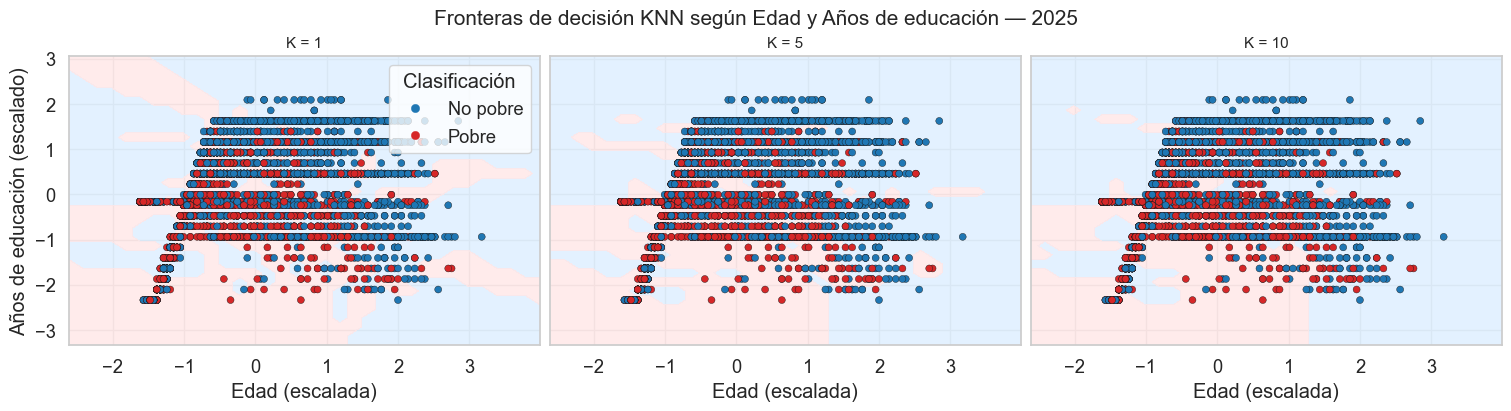

In [14]:
# Variables a graficar
vars_2D = ['CH06', 'educ']  # 'educ' = años de educación, 'CH06' = edad
Ks = [1, 5, 10]

# Paletas de colores
cmap_bg = ListedColormap(["#ddeeff", "#ffe6e6"])  # fondo azul/rojo suave
cmap_pts = ListedColormap(["#1f77b4", "#d62728"])  # puntos azul/rojo

# Solo año 2025
X_train_year = X_train_2025[vars_2D].copy()
y_train_year = y_train_2025.copy()

# Escalado
scaler = StandardScaler().fit(X_train_year)
X_scaled = scaler.transform(X_train_year)

# Malla para frontera
h = 0.2
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

fig, axes = plt.subplots(1, len(Ks), figsize=(5 * len(Ks), 4), constrained_layout=True)

for j, K in enumerate(Ks):
    ax = axes[j]
    knn = KNeighborsClassifier(n_neighbors=K)
    knn.fit(X_scaled, y_train_year)

    # Predicción sobre la malla
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = knn.predict(grid_points).reshape(xx.shape)

    # Fondo con la frontera
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=cmap_bg, levels=[-0.5, 0.5, 1.5])

    # Puntos de entrenamiento
    scatter = ax.scatter(
        X_scaled[:, 0], X_scaled[:, 1],
        c=y_train_year, cmap=cmap_pts, s=25, edgecolor="k", linewidth=0.3,  marker='o'
    )

    ax.set_title(f"K = {K}", fontsize=11)
    ax.set_xlabel("Edad (escalada)")
    
    # Solo el primer subplot tiene eje y y leyenda
    if j == 0:
        ax.set_ylabel("Años de educación (escalado)")
        handles, _ = scatter.legend_elements()
        ax.legend(handles, ["No pobre", "Pobre"], title="Clasificación", loc="upper right")
    else:
        ax.set_yticklabels([])  # quitar etiquetas del eje y

plt.suptitle("Fronteras de decisión KNN según Edad y Años de educación — 2025", fontsize=15)
plt.show()


## Ejercicio 7)

K óptimo según CV = 16 (Accuracy promedio = 0.7079)


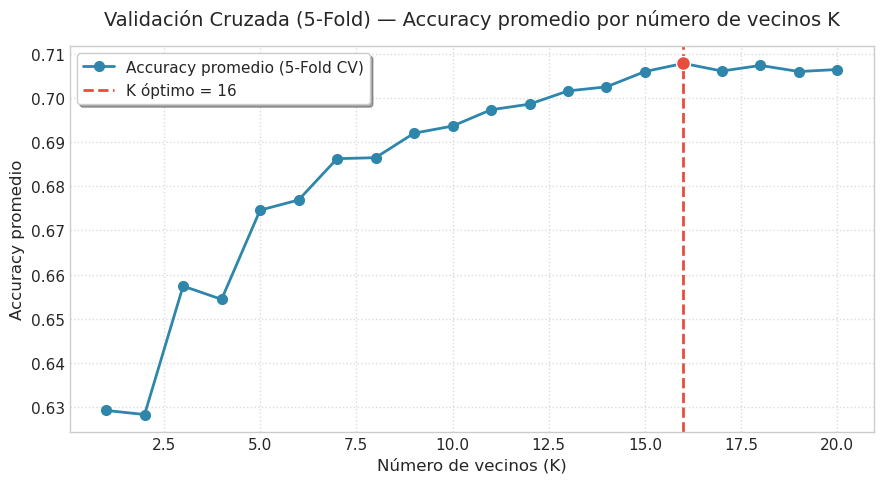

In [15]:
# --- Datos ---
X = respondieron_2025[X_vars]
y = respondieron_2025[y_var]

# --- Escalado ---
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)

# --- Rango de Ks a probar ---
Ks = range(1, 21)

# --- Validación cruzada 5-fold ---
accuracies = []

for K in Ks:
    knn = KNeighborsClassifier(n_neighbors=K)
    scores = cross_val_score(knn, X_scaled, y, cv=5, scoring='accuracy')
    accuracies.append(scores.mean())

# --- Identificar el K óptimo ---
K_opt = Ks[np.argmax(accuracies)]
max_acc = max(accuracies)
print(f"K óptimo según CV = {K_opt} (Accuracy promedio = {max_acc:.4f})")

# --- Estilo visual ---
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

# --- Gráfico ---
plt.figure(figsize=(9, 5))
plt.plot(Ks, accuracies, marker='o', color='#2E86AB', linewidth=2, markersize=7, label='Accuracy promedio (5-Fold CV)')
plt.axvline(K_opt, color='#E74C3C', linestyle='--', linewidth=2, label=f'K óptimo = {K_opt}')

# --- Detalles visuales ---
plt.scatter(K_opt, max_acc, color='#E74C3C', s=100, edgecolor='white', zorder=5)
plt.title("Validación Cruzada (5-Fold) — Accuracy promedio por número de vecinos K", pad=15)
plt.xlabel("Número de vecinos (K)")
plt.ylabel("Accuracy promedio")
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(frameon=True, shadow=True)
plt.tight_layout()
plt.show()


In [16]:
# --- Mostrar el K óptimo ---
K_optimo = Ks[np.argmax(accuracies)]
print(f"K óptimo según CV = {K_optimo} (accuracy promedio = {max(accuracies):.3f})")

# --- Entrenar el modelo final con ese K ---
knn_cv = KNeighborsClassifier(n_neighbors=K_optimo)
knn_cv.fit(X_scaled, y)


K óptimo según CV = 16 (accuracy promedio = 0.708)


KNeighborsClassifier(n_neighbors=16)

# PARTE D: Desempeño de modelos, elección y predicción afuera de muestra

## Ejercicio 8)

In [42]:
y_pred_logit = (logit_2025.predict(X_test_2025) > 0.5).astype(int)

In [29]:
# --- Predicciones sobre el conjunto de test ---
X_test_knn = X_test_2025[X_vars]            # mismas columnas que en el entrenamiento
X_test_knn_scaled = scaler.transform(X_test_knn)  # mismo escalador usado antes

y_pred_knn = knn_cv.predict(X_test_knn_scaled)

### Matriz de Confusión

Matriz de Confusión - Logit:
 [[1101  357]
 [ 440  698]]
Matriz de Confusión - KNN:
 [[1168  290]
 [ 390  748]]


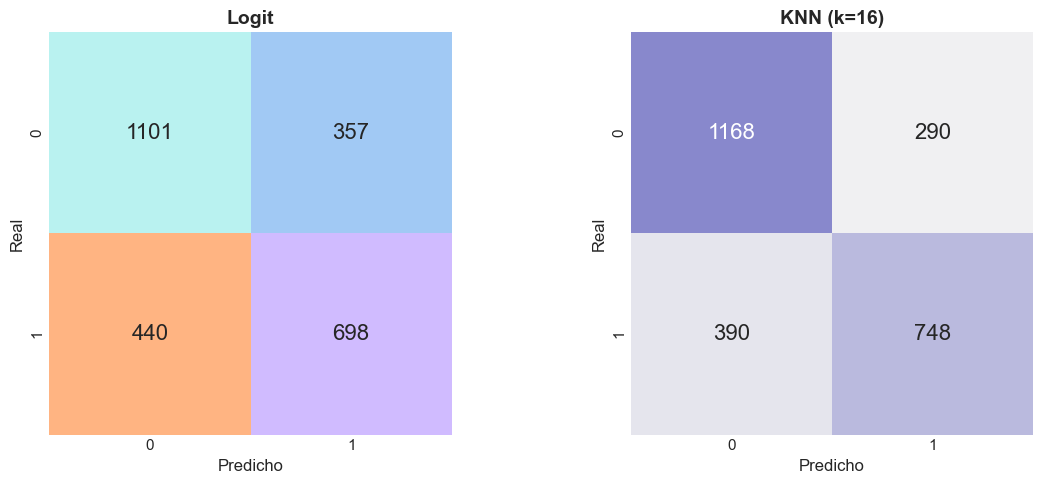

In [46]:
# Fuente y estilo general

rcParams['font.family'] = 'serif'
rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-white')


# Matrices de confusión

cm_logit = confusion_matrix(y_test_2025, y_pred_logit)
cm_knn = confusion_matrix(y_test_2025, y_pred_knn)

print("Matriz de Confusión - Logit:\n", cm_logit)
print("Matriz de Confusión - KNN:\n", cm_knn)


# Figura y paletas (manteniendo tus colores originales)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

cmap_logit = sns.color_palette("pastel", as_cmap=True)
cmap_knn = sns.color_palette("light:#88c", as_cmap=True)


# Heatmap Logit

sns.heatmap(
    cm_logit, annot=True, fmt="d", cmap=cmap_logit,
    cbar=False, square=True, linewidths=0,
    annot_kws={"size": 16}, ax=ax[0]
)
ax[0].set_title("Logit", fontsize=14, fontweight='bold')
ax[0].set_xlabel("Predicho")
ax[0].set_ylabel("Real")

# Heatmap KNN

sns.heatmap(
    cm_knn, annot=True, fmt="d", cmap=cmap_knn,
    cbar=False, square=True, linewidths=0,
    annot_kws={"size": 16}, ax=ax[1]
)
ax[1].set_title(f"KNN (k={knn_cv.n_neighbors})", fontsize=14, fontweight='bold')
ax[1].set_xlabel("Predicho")
ax[1].set_ylabel("Real")  # opcional: dejar vacío si querés simetría visual

plt.tight_layout()
plt.show()


### Curva ROC

In [47]:
# --- Probabilidades predichas ---
y_pred_prob_logit = logit_2025.predict(sm.add_constant(X_test_2025))
y_pred_prob_knn = knn_cv.predict_proba(X_test_knn_scaled)[:, 1]


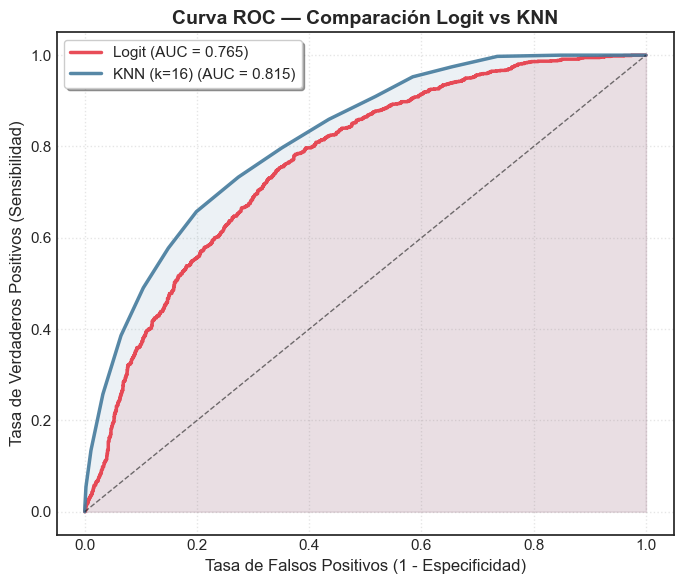

In [48]:
# Estilo general
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-white')

# --- Curva ROC ---
fpr_logit, tpr_logit, _ = roc_curve(y_test_2025, y_pred_prob_logit)
fpr_knn, tpr_knn, _ = roc_curve(y_test_2025, y_pred_prob_knn)

roc_auc_logit = auc(fpr_logit, tpr_logit)
roc_auc_knn = auc(fpr_knn, tpr_knn)

# --- Paleta y diseño ---
sns.set_palette("pastel")
plt.figure(figsize=(7,6))

# Logit
plt.plot(fpr_logit, tpr_logit, color="#E63946", lw=2.5,
         label=f'Logit (AUC = {roc_auc_logit:.3f})', alpha=0.9)
plt.fill_between(fpr_logit, tpr_logit, alpha=0.1, color="#E63946")

# KNN
plt.plot(fpr_knn, tpr_knn, color="#457B9D", lw=2.5,
         label=f'KNN (k=16) (AUC = {roc_auc_knn:.3f})', alpha=0.9)
plt.fill_between(fpr_knn, tpr_knn, alpha=0.1, color="#457B9D")

# Línea diagonal
plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6)

# Ejes y título
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
plt.title('Curva ROC — Comparación Logit vs KNN', fontsize=14, fontweight='bold')

# Cuadrícula sutil y leyenda
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(frameon=True, fancybox=True, shadow=True, fontsize=11)

plt.tight_layout()
plt.show()


### Métricas Adicionales

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

metrics = pd.DataFrame({
    'Modelo': ['Logit', 'KNN (k=16)'],
    'Accuracy': [
        accuracy_score(y_test_2025, y_pred_logit),
        accuracy_score(y_test_2025, y_pred_knn)
    ],
    'Precision': [
        precision_score(y_test_2025, y_pred_logit),
        precision_score(y_test_2025, y_pred_knn)
    ],
    'Recall': [
        recall_score(y_test_2025, y_pred_logit),
        recall_score(y_test_2025, y_pred_knn)
    ],
    'F1-Score': [
        f1_score(y_test_2025, y_pred_logit),
        f1_score(y_test_2025, y_pred_knn)
    ],
    'AUC': [roc_auc_logit, roc_auc_knn]
})

print("\n Métricas comparativas:")
print(metrics)



 Métricas comparativas:
       Modelo  Accuracy  Precision    Recall  F1-Score       AUC
0       Logit  0.692989   0.661611  0.613357  0.636571  0.764837
1  KNN (k=16)  0.738059   0.720617  0.657293  0.687500  0.815265


## Ejercicio 10)

In [53]:
from sklearn.preprocessing import StandardScaler

# --- Seleccionar las variables X ---
X_noresp_2025 = norespondieron_2025[X_vars].copy()

# --- Escalar usando el mismo scaler que se usó en entrenamiento ---
X_noresp_scaled = scaler.transform(X_noresp_2025)  # numpy array


In [54]:
# --- Predicción con KNN ---
# Probabilidades
y_pred_prob_noresp = knn_cv.predict_proba(X_noresp_scaled)[:, 1]

# Clasificación binaria
y_pred_noresp = (y_pred_prob_noresp > 0.5).astype(int)

# --- Guardar resultados ---
norespondieron_2025 = norespondieron_2025.reset_index(drop=True)  # limpiar índices
norespondieron_2025["prob_pobre"] = y_pred_prob_noresp
norespondieron_2025["pobre_pred"] = y_pred_noresp

# --- Calcular proporción de pobres ---
prop_pobres = norespondieron_2025["pobre_pred"].mean()
print(f"Proporción estimada de personas pobres entre los no respondieron (2025): {prop_pobres:.3f}")


Proporción estimada de personas pobres entre los no respondieron (2025): 0.384
